In [6]:
# !pip uninstall numpy -y

Found existing installation: numpy 2.0.2
Uninstalling numpy-2.0.2:
  Successfully uninstalled numpy-2.0.2


In [7]:
# !pip install numpy==1.26

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.5/58.5 kB 2.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.9/17.9 MB 42.0 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
music21 9.9.1 requires numpy>=1.26.4, but you have numpy 1.26.0 which is incompatible.
jax 0.7.2 requires numpy>=2.0, but you have numpy 1.26.0 which is incompatible.
opencv-python-headless 4.12.0.88 requires numpy<2.3.0,>=2; python_version >= "3.9", but you have numpy 1.26.0 which is incompatible.
opencv-contrib-python 4.12.0.88 requires numpy<2.3.0,>=2; python_version >= "3.9", but you have numpy 1.26.0 which is incompatible.
pytensor 2.35.1 requires numpy>=2.0, but you have numpy 1.26.0 which is incompatible.
opencv-python 4.12.0.88 requires numpy<2.3.0,>=2; python_version >= "3.9", but you have numpy 1.26.0 which is incompatible.
jaxlib 0.7.2 requires nu

In [1]:
! nvidia-smi

Mon Dec  1 01:23:00 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 550.54.15              Driver Version: 550.54.15      CUDA Version: 12.4     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   43C    P8              9W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

### Downloading Data

In [2]:
! rm -rf cs589assignment3/
! git clone https://github.com/guanqun-yang/cs589assignment4.git cs589assignment3

Cloning into 'cs589assignment3'...
remote: Enumerating objects: 18, done.
remote: Total 18 (delta 0), reused 0 (delta 0), pack-reused 18 (from 1)
Receiving objects: 100% (18/18), 1.61 MiB | 2.02 MiB/s, done.
Resolving deltas: 100% (2/2), done.


In [3]:
!pip install transformers datasets evaluate flaml

In [4]:
!pip install --upgrade transformers

In [5]:
import time
import numpy as np
import torch
from transformers import AutoTokenizer, AutoModelForSequenceClassification, Trainer, TrainingArguments
from datasets import load_dataset
import evaluate
import matplotlib.pyplot as plt
from flaml import tune
from flaml import BlendSearch
import itertools


In [6]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print(device)

cuda


In [7]:
\data_files = {
    "train": "./cs589assignment3/python/train.json",
    "validation": "./cs589assignment3/python/val.json",
    "test": "./cs589assignment3/python/test.json"
}

dataset = load_dataset("json", data_files=data_files)

Generating train split: 0 examples [00:00, ? examples/s]

Generating validation split: 0 examples [00:00, ? examples/s]

Generating test split: 0 examples [00:00, ? examples/s]

In [8]:
class SafeLabelEncoder:
    def __init__(self):
        self.classes_ = {}
        self.inverse_classes_ = {}

    def fit(self, labels):
        unique_labels = sorted(set(labels))
        self.classes_ = {label: idx for idx, label in enumerate(unique_labels)}
        self.inverse_classes_ = {idx: label for label, idx in self.classes_.items()}

    def transform(self, labels):
        # If label not seen, return -1
        return [self.classes_.get(label, -1) for label in labels]

    def inverse_transform(self, indices):
        return [self.inverse_classes_.get(idx, "unknown") for idx in indices]

# Fit encoder only on train first tag
all_first_tags = [tags[0] for tags in dataset["train"]["tags"]]
safe_encoder = SafeLabelEncoder()
safe_encoder.fit(all_first_tags)

# Calculate correct number of labels
num_labels = len(safe_encoder.classes_)
print("Number of labels:", num_labels)

def encode_labels(examples):
    first_tag = []
    for tags in examples["tags"]:
        if isinstance(tags, list) and len(tags) > 0:
            first_tag.append(tags[0])
        else:
            first_tag.append("unknown")

    labels = safe_encoder.transform(first_tag)
    return {"labels": labels}

dataset = dataset.map(encode_labels, batched=True)

# Filter out invalid labels (-1)
def filter_invalid(example):
    return example["labels"] != -1

dataset["train"] = dataset["train"].filter(filter_invalid)
dataset["validation"] = dataset["validation"].filter(filter_invalid)
dataset["test"] = dataset["test"].filter(filter_invalid)

Number of labels: 50


Map:   0%|          | 0/4678 [00:00<?, ? examples/s]

Map:   0%|          | 0/585 [00:00<?, ? examples/s]

Map:   0%|          | 0/585 [00:00<?, ? examples/s]

Filter:   0%|          | 0/4678 [00:00<?, ? examples/s]

Filter:   0%|          | 0/585 [00:00<?, ? examples/s]

Filter:   0%|          | 0/585 [00:00<?, ? examples/s]

In [9]:
tokenizer = AutoTokenizer.from_pretrained("bert-base-uncased")

def preprocess_function(examples):
    return tokenizer(examples["question"], padding="max_length", truncation=True, max_length=256)

tokenized_datasets = dataset.map(preprocess_function, batched=True)
tokenized_datasets.set_format("torch")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

Map:   0%|          | 0/4678 [00:00<?, ? examples/s]

Map:   0%|          | 0/585 [00:00<?, ? examples/s]

In [10]:
from sklearn.metrics import ndcg_score

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = torch.softmax(torch.tensor(logits), dim=1).numpy()

    labels = np.eye(predictions.shape[1])[labels]

    ndcg = ndcg_score(labels, predictions)

    return {"ndcg": ndcg}

In [11]:
import os
os.environ["WANDB_DISABLED"] = "true"

In [12]:
learning_rates = [1e-7, 1e-6, 1e-5]
epochs_list = [1, 2, 3, 4, 5]
batch_size = 4

best_ndcg = 0
best_config = None
results_grid = []
start_time = time.time()

for lr, epochs in itertools.product(learning_rates, epochs_list):
    model = AutoModelForSequenceClassification.from_pretrained("bert-base-uncased", num_labels=num_labels).to(device)

    args = TrainingArguments(
        output_dir="./results",
        learning_rate=lr,
        per_device_train_batch_size=batch_size,
        per_device_eval_batch_size=batch_size,
        num_train_epochs=epochs,
        weight_decay=0.01,
        logging_dir='./logs',
        fp16=True,
    )

    trainer = Trainer(
        model=model,
        args=args,
        train_dataset=tokenized_datasets["train"],
        eval_dataset=tokenized_datasets["validation"],
        compute_metrics=compute_metrics,
    )

    trainer.train()
    eval_results = trainer.evaluate()
    ndcg_score_val = eval_results["eval_ndcg"]
    elapsed = time.time() - start_time
    results_grid.append((elapsed, ndcg_score_val))

    if ndcg_score_val > best_ndcg:
        best_ndcg = ndcg_score_val
        best_config = (lr, epochs)

print("Best Config (Grid):", best_config, "NDCG:", best_ndcg)


model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Using the `WANDB_DISABLED` environment variable is deprecated and will be removed in v5. Use the --report_to flag to control the integrations used for logging result (for instance --report_to none).


Step,Training Loss
500,3.912700
1000,3.891500


Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Using the `WANDB_DISABLED` environment variable is deprecated and will be removed in v5. Use the --report_to flag to control the integrations used for logging result (for instance --report_to none).


Step,Training Loss
500,3.929200
1000,3.891100
1500,3.886600
2000,3.878200


...

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Using the `WANDB_DISABLED` environment variable is deprecated and will be removed in v5. Use the --report_to flag to control the integrations used for logging result (for instance --report_to none).


Step,Training Loss
500,3.588800
1000,3.027300
1500,2.655400
2000,2.389300
2500,2.205500
3000,2.042500
3500,1.981200
4000,1.826300
4500,1.828400


Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Using the `WANDB_DISABLED` environment variable is deprecated and will be removed in v5. Use the --report_to flag to control the integrations used for logging result (for instance --report_to none).


Step,Training Loss
500,3.501700
1000,2.873600
1500,2.496400
2000,2.252600
2500,2.107700
3000,1.912400
3500,1.857700
4000,1.660600
4500,1.652100
5000,1.608200


Best Config (Grid): (1e-05, 5) NDCG: 0.7496673342204263


In [13]:
!pip install "ray[tune]" -q


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 102.2/102.2 kB 5.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 87.2/87.2 kB 6.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.3/72.3 MB 14.3 MB/s eta 0:00:00


In [14]:
from flaml import tune
from ray import air

def trainable(config):
    lr = config["lr"]
    epochs = config["epochs"]

    start = time.time()
    model = AutoModelForSequenceClassification.from_pretrained("bert-base-uncased", num_labels=num_labels).to(device)

    args = TrainingArguments(
        output_dir="./results",
        learning_rate=lr,
        per_device_train_batch_size=batch_size,
        per_device_eval_batch_size=batch_size,
        num_train_epochs=epochs,
        weight_decay=0.01,
        logging_dir='./logs',
        fp16=True,
    )

    trainer = Trainer(
        model=model,
        args=args,
        train_dataset=tokenized_datasets["train"],
        eval_dataset=tokenized_datasets["validation"],
        compute_metrics=compute_metrics,
    )

    trainer.train()
    eval_results = trainer.evaluate()
    ndcg_score_val = eval_results["eval_ndcg"]
    wct = time.time() - start

    tune.report(ndcg=ndcg_score_val, wall_clock=wct)

search_space = {
    "lr": tune.loguniform(1e-7, 1e-5),
    "epochs": tune.randint(1, 6),
}

analysis = tune.run(
    trainable,
    config=search_space,
    resources_per_trial={"gpu": 1},
    num_samples=15,
    low_cost_partial_config={"n_epoch": 1},
    metric="ndcg",
    mode="max",
    n_concurrent_trials=1,
)


flaml_results = []
best_ndcg_flaml = 0

for trial in analysis.trials:
    result = trial.last_result
    wct = result["wall_clock"]
    ndcg = result["ndcg"]
    flaml_results.append((wct, ndcg))

    if ndcg > best_ndcg_flaml:
        best_ndcg_flaml = ndcg

print("Best NDCG (FLAML):", best_ndcg_flaml)


[flaml.tune.logger: 12-01 03:22:32] {589} WARNING - Using CFO for search. To use BlendSearch, run: pip install flaml[blendsearch]
[flaml.tune.logger: 12-01 03:22:32] {891} INFO - trial 1 config: {'n_epoch': 1, 'lr': 1.5662610420278312e-07, 'epochs': 1}


Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Using the `WANDB_DISABLED` environment variable is deprecated and will be removed in v5. Use the --report_to flag to control the integrations used for logging result (for instance --report_to none).


Step,Training Loss
500,3.925600
1000,3.920100


[flaml.tune.logger: 12-01 03:25:29] {891} INFO - trial 2 config: {'n_epoch': 1, 'lr': 1e-07, 'epochs': 1}


Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Using the `WANDB_DISABLED` environment variable is deprecated and will be removed in v5. Use the --report_to flag to control the integrations used for logging result (for instance --report_to none).


...

Step,Training Loss
500,3.899600
1000,3.855000
1500,3.820500
2000,3.787900


[flaml.tune.logger: 12-01 04:56:24] {891} INFO - trial 15 config: {'n_epoch': 1, 'lr': 6.259914989487211e-07, 'epochs': 5}


Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Using the `WANDB_DISABLED` environment variable is deprecated and will be removed in v5. Use the --report_to flag to control the integrations used for logging result (for instance --report_to none).


Step,Training Loss
500,3.831300
1000,3.721200
1500,3.655700
2000,3.586600
2500,3.554700
3000,3.539600
3500,3.516900
4000,3.468100
4500,3.473900
5000,3.480000


Best NDCG (FLAML): 0.5792692161143846


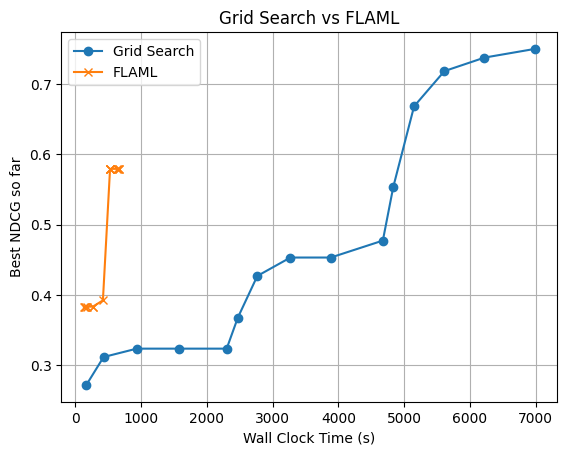

In [15]:
def accumulate_best(results):
    best = 0
    acc = []
    for t, score in results:
        best = max(best, score)
        acc.append((t, best))
    return acc

results_grid_sorted = sorted(results_grid, key=lambda x: x[0])
flaml_results_sorted = sorted(flaml_results, key=lambda x: x[0])

acc_grid = accumulate_best(results_grid_sorted)
acc_flaml = accumulate_best(flaml_results_sorted)

grid_times, grid_ndcg = zip(*acc_grid)
flaml_times, flaml_ndcg = zip(*acc_flaml)

plt.plot(grid_times, grid_ndcg, label="Grid Search", marker='o')
plt.plot(flaml_times, flaml_ndcg, label="FLAML", marker='x')
plt.xlabel("Wall Clock Time (s)")
plt.ylabel("Best NDCG so far")
plt.title("Grid Search vs FLAML")
plt.legend()
plt.grid(True)
plt.show()


### FLAML reaches strong NDCG scores in a fraction of the time required by grid search, demonstrating superior efficiency and search intelligence.